In [1]:
# ============================================================
# 🔧 PLOT CONFIGURATION (TUNE EVERYTHING HERE)
# ============================================================

FIGSIZE = (20, 6)

LINE_WIDTH = 2
DOT_LINE_STYLE = ":"       # V1
SOLID_LINE_STYLE = "-"     # V2

MARKER_STYLE = "o"
MARKER_SIZE = 6

TITLE_TEXT = ""
YLABEL_TEXT = "Error Rate (%)"
LABEL_FONTSIZE = 14

XTICK_FONTSIZE = 16
YTICK_FONTSIZE = 16

LEGEND_FONTSIZE = 18
LEGEND_NCOL = 3

GRID_MAJOR_ALPHA = 0.9
GRID_MINOR_ALPHA = 0.1

# ============================================================
# 🔧 PLOT CONFIGURATION (TUNE EVERYTHING HERE)
# ============================================================

In [2]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# -----------------------
# 1) Parse log lines (counts + rates)
# -----------------------
LINE_RE = re.compile(
    r"^\s*(?P<idx>\d+)\s*\|\s*(?P<attr>[^|]+?)\s*\|\s*"
    r"TA=\s*(?P<TA>\d+)\s+TR=\s*(?P<TR>\d+)\(CD=\s*(?P<CD>\d+),DE=\s*(?P<DE>\d+)\)\s+"
    r"FA=\s*(?P<FA>\d+)\s+FR=\s*(?P<FR>\d+)\s*\|\s*"
    r"FAR=\s*(?P<far>[\d.]+)%\s*FRR=\s*(?P<frr>[\d.]+)%\s*DER=\s*(?P<der>[\d.]+)%",
    re.MULTILINE
)

def parse_attr_log(text: str) -> pd.DataFrame:
    rows = []
    for m in LINE_RE.finditer(text):
        rows.append({
            "idx": int(m.group("idx")),
            "attr": m.group("attr").strip(),
            "TA": int(m.group("TA")),
            "TR": int(m.group("TR")),
            "FA": int(m.group("FA")),
            "FR": int(m.group("FR")),
            "CD": int(m.group("CD")),
            "DE": int(m.group("DE")),
            "FAR%": float(m.group("far")),
            "FRR%": float(m.group("frr")),
            "DER%": float(m.group("der")),
        })
    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No rows parsed. Check the log format.")
    return df

def recompute_rates_from_counts(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["FAR%"] = np.where((out["FA"] + out["TR"]) > 0,
                           out["FA"] / (out["FA"] + out["TR"]) * 100.0, 0.0)
    out["FRR%"] = np.where((out["FR"] + out["TA"]) > 0,
                           out["FR"] / (out["FR"] + out["TA"]) * 100.0, 0.0)
    out["DER%"] = np.where((out["CD"] + out["DE"]) > 0,
                           out["DE"] / (out["CD"] + out["DE"]) * 100.0, 0.0)
    return out

# -----------------------
# 2) Collapse V2 tone-v2 attrs -> tone-1..4 (sum counts then recompute)
# -----------------------
TONE_PITCH_TARGETS = {
    1: {"start": 5, "mid": 5, "end": 5},  # tone-1
    2: {"start": 3, "mid": 4, "end": 5},  # tone-2
    3: {"start": 2, "mid": 1, "end": 4},  # tone-3
    4: {"start": 5, "mid": 3, "end": 1},  # tone-4
}

def collapse_v2_to_tone14_counts(df_v2: pd.DataFrame,
                                 prefix_start="start-",
                                 prefix_mid="mid-",
                                 prefix_end="end-") -> pd.DataFrame:
    rows = []
    for tone_id, t in TONE_PITCH_TARGETS.items():
        keys = {f"{prefix_start}{t['start']}", f"{prefix_mid}{t['mid']}", f"{prefix_end}{t['end']}"}
        sub = df_v2[df_v2["attr"].isin(keys)]
        agg = {
            "attr": f"tone-{tone_id}",
            "TA": int(sub["TA"].sum()) if not sub.empty else 0,
            "TR": int(sub["TR"].sum()) if not sub.empty else 0,
            "FA": int(sub["FA"].sum()) if not sub.empty else 0,
            "FR": int(sub["FR"].sum()) if not sub.empty else 0,
            "CD": int(sub["CD"].sum()) if not sub.empty else 0,
            "DE": int(sub["DE"].sum()) if not sub.empty else 0,
        }
        rows.append(agg)
    return recompute_rates_from_counts(pd.DataFrame(rows))

def apply_v2_tone_collapse(df_v2: pd.DataFrame,
                           prefix_start="start-",
                           prefix_mid="mid-",
                           prefix_end="end-") -> pd.DataFrame:
    """
    Remove V2's start/mid/end tone attrs; add back tone-1..4 aggregated rows.
    """
    # identify all tone-v2 attrs to drop
    tone_like = set()
    for tone_id, t in TONE_PITCH_TARGETS.items():
        tone_like |= {
            f"{prefix_start}{t['start']}",
            f"{prefix_mid}{t['mid']}",
            f"{prefix_end}{t['end']}",
        }

    df_keep = df_v2[~df_v2["attr"].isin(tone_like)].copy()
    df_tone14 = collapse_v2_to_tone14_counts(df_v2, prefix_start, prefix_mid, prefix_end)

    # concat: keep all non-tone-v2 attrs + add tone-1..4
    out = pd.concat([df_keep, df_tone14], ignore_index=True)
    return out

# -----------------------
# 3) Make a shared X-axis order (use V1 order by FAR% by default)
# -----------------------
def build_x_order(df_v1: pd.DataFrame,
                  df_v2: pd.DataFrame,
                  sort_by="FAR%") -> list:
    """
    Default: order by V1's sort_by ascending.
    If V2 has extra attrs not in V1, append them at end (alphabetical).
    """
    v1_order = df_v1.sort_values(sort_by)["attr"].tolist()
    v1_set = set(v1_order)

    extra_v2 = sorted([a for a in df_v2["attr"].unique().tolist() if a not in v1_set])
    return v1_order + extra_v2

# -----------------------
# 4) Plot: FAR/FRR/DER for V1(dotted) vs V2(solid), colors unchanged
# -----------------------
from matplotlib.lines import Line2D

def plot_all_attrs_v1_v2(df_v1: pd.DataFrame,
                         df_v2: pd.DataFrame,
                         x_order: list):

    def to_series(df, col):
        s = df.set_index("attr")[col]
        return [s.get(a, np.nan) for a in x_order]

    x = np.arange(len(x_order))

    plt.figure(figsize=FIGSIZE)

    metric_colors = {
        "FAR%": "C0",
        "FRR%": "C1",
        "DER%": "C2"
    }

    for metric, color in metric_colors.items():

        y1 = to_series(df_v1, metric)
        y2 = to_series(df_v2, metric)

        # V1 (CAT) dotted
        plt.plot(
            x, y1,
            linestyle=DOT_LINE_STYLE,
            linewidth=LINE_WIDTH,
            marker=MARKER_STYLE,
            markersize=MARKER_SIZE,
            color=color,
        )

        # V2 (PT) solid
        plt.plot(
            x, y2,
            linestyle=SOLID_LINE_STYLE,
            linewidth=LINE_WIDTH,
            marker=MARKER_STYLE,
            markersize=MARKER_SIZE,
            color=color,
        )

    # Axis labels
    plt.xticks(x, x_order, rotation=90, fontsize=XTICK_FONTSIZE)
    plt.yticks(fontsize=YTICK_FONTSIZE)
    plt.ylabel(YLABEL_TEXT, fontsize=LABEL_FONTSIZE)

    # Grid
    plt.grid(True, which="major", linestyle="--", alpha=GRID_MAJOR_ALPHA)
    plt.minorticks_on()
    plt.grid(True, which="minor", linestyle=":", alpha=GRID_MINOR_ALPHA)


    legend_elements = [

        # 第一列（Metrics）
        Line2D([0], [0], color="C0", lw=LINE_WIDTH, label="FAR"),
        Line2D([0], [0], color="C1", lw=LINE_WIDTH, label="FRR"),
        Line2D([0], [0], color="C2", lw=LINE_WIDTH, label="DER"),

        # 第二列（Systems）
        Line2D([0], [0], color="black", lw=LINE_WIDTH,
            linestyle=DOT_LINE_STYLE, label="Tone-CAT"),
        Line2D([0], [0], color="black", lw=LINE_WIDTH,
            linestyle=SOLID_LINE_STYLE, label="Tone-PT"),
    ]

    plt.legend(
        handles=legend_elements,
        frameon=False,
        fontsize=LEGEND_FONTSIZE,
        ncol=2,
        columnspacing=2.0,
        handletextpad=0.8,
        borderaxespad=0.5
    )


    # 不改 padding
    plt.xlim(-1, len(x_order))

    plt.tight_layout()
    plt.show()


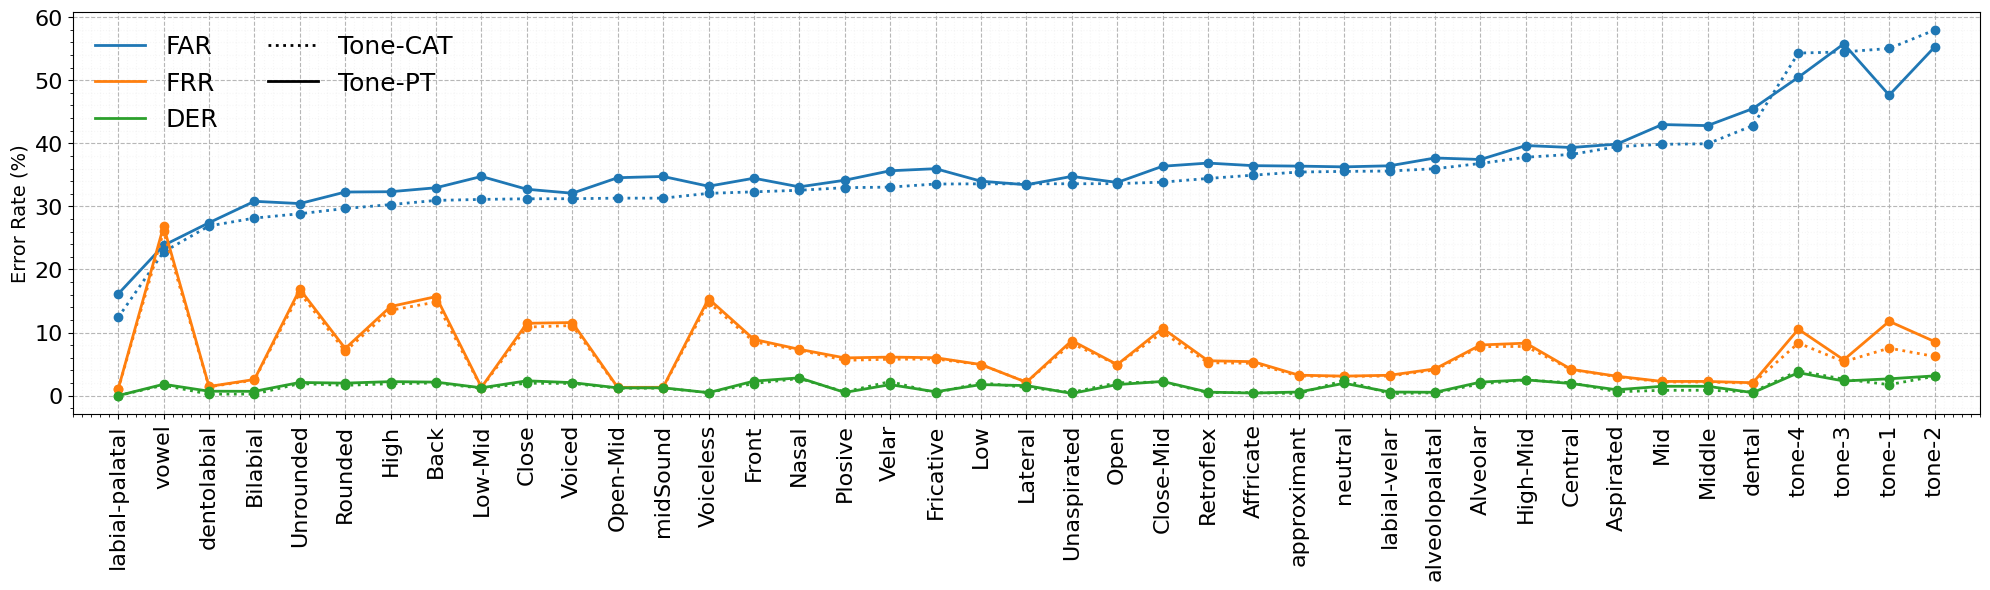

In [3]:
# -----------------------
# Example usage
# -----------------------
# Option A) from strings:
log_v1_text = """====================================================================================================
FINAL ATTRIBUTE-LEVEL MDD EVALUATION
====================================================================================================
34 | labial-palatal   | TA= 49001 TR=   212(CD=   212,DE=     0) FA=    30 FR=   493 | FAR= 12.40% FRR=  1.00% DER=  0.00%
36 | vowel            | TA= 18511 TR= 19079(CD= 18764,DE=   315) FA=  5631 FR=  6515 | FAR= 22.79% FRR= 26.03% DER=  1.65%
07 | dentolabial      | TA= 48458 TR=   432(CD=   431,DE=     1) FA=   159 FR=   687 | FAR= 26.90% FRR=  1.40% DER=  0.23%
05 | Bilabial         | TA= 46869 TR=  1215(CD=  1212,DE=     3) FA=   476 FR=  1176 | FAR= 28.15% FRR=  2.45% DER=  0.25%
16 | Unrounded        | TA= 29029 TR= 10708(CD= 10504,DE=   204) FA=  4340 FR=  5659 | FAR= 28.84% FRR= 16.31% DER=  1.91%
17 | Rounded          | TA= 40334 TR=  4470(CD=  4397,DE=    73) FA=  1886 FR=  3046 | FAR= 29.67% FRR=  7.02% DER=  1.63%
26 | High             | TA= 32684 TR=  8319(CD=  8162,DE=   157) FA=  3614 FR=  5119 | FAR= 30.29% FRR= 13.54% DER=  1.89%
20 | Back             | TA= 31467 TR=  8830(CD=  8653,DE=   177) FA=  3958 FR=  5481 | FAR= 30.95% FRR= 14.83% DER=  2.00%
29 | Low-Mid          | TA= 48627 TR=   341(CD=   337,DE=     4) FA=   154 FR=   614 | FAR= 31.11% FRR=  1.25% DER=  1.17%
21 | Close            | TA= 35824 TR=  6564(CD=  6435,DE=   129) FA=  2978 FR=  4370 | FAR= 31.21% FRR= 10.87% DER=  1.97%
03 | Voiced           | TA= 35490 TR=  6749(CD=  6619,DE=   130) FA=  3063 FR=  4434 | FAR= 31.22% FRR= 11.11% DER=  1.93%
24 | Open-Mid         | TA= 48626 TR=   340(CD=   336,DE=     4) FA=   155 FR=   615 | FAR= 31.31% FRR=  1.25% DER=  1.18%
35 | midSound         | TA= 48626 TR=   340(CD=   336,DE=     4) FA=   155 FR=   615 | FAR= 31.31% FRR=  1.25% DER=  1.18%
02 | Voiceless        | TA= 31278 TR=  8841(CD=  8799,DE=    42) FA=  4174 FR=  5443 | FAR= 32.07% FRR= 14.82% DER=  0.48%
18 | Front            | TA= 38818 TR=  4939(CD=  4844,DE=    95) FA=  2358 FR=  3621 | FAR= 32.31% FRR=  8.53% DER=  1.92%
06 | Nasal            | TA= 40436 TR=  4148(CD=  4035,DE=   113) FA=  2003 FR=  3149 | FAR= 32.56% FRR=  7.22% DER=  2.72%
04 | Plosive          | TA= 42422 TR=  3217(CD=  3198,DE=    19) FA=  1582 FR=  2515 | FAR= 32.97% FRR=  5.60% DER=  0.59%
15 | Velar            | TA= 43077 TR=  2693(CD=  2633,DE=    60) FA=  1330 FR=  2636 | FAR= 33.06% FRR=  5.77% DER=  2.23%
08 | Fricative        | TA= 42962 TR=  2739(CD=  2727,DE=    12) FA=  1383 FR=  2652 | FAR= 33.55% FRR=  5.81% DER=  0.44%
30 | Low              | TA= 43929 TR=  2352(CD=  2304,DE=    48) FA=  1189 FR=  2266 | FAR= 33.58% FRR=  4.91% DER=  2.04%
00 | Unaspirated      | TA= 39556 TR=  4396(CD=  4373,DE=    23) FA=  2223 FR=  3561 | FAR= 33.59% FRR=  8.26% DER=  0.52%
12 | Lateral          | TA= 47654 TR=   690(CD=   681,DE=     9) FA=   349 FR=  1043 | FAR= 33.59% FRR=  2.14% DER=  1.30%
25 | Open             | TA= 43925 TR=  2351(CD=  2303,DE=    48) FA=  1190 FR=  2270 | FAR= 33.61% FRR=  4.91% DER=  2.04%
22 | Close-Mid        | TA= 37076 TR=  5641(CD=  5519,DE=   122) FA=  2887 FR=  4132 | FAR= 33.85% FRR= 10.03% DER=  2.16%
13 | Retroflex        | TA= 43849 TR=  2278(CD=  2267,DE=    11) FA=  1196 FR=  2413 | FAR= 34.43% FRR=  5.22% DER=  0.48%
10 | Affricate        | TA= 43534 TR=  2502(CD=  2490,DE=    12) FA=  1345 FR=  2355 | FAR= 34.96% FRR=  5.13% DER=  0.48%
32 | approximant      | TA= 46337 TR=  1238(CD=  1234,DE=     4) FA=   680 FR=  1481 | FAR= 35.45% FRR=  3.10% DER=  0.32%
31 | neutral          | TA= 46046 TR=  1441(CD=  1406,DE=    35) FA=   795 FR=  1454 | FAR= 35.55% FRR=  3.06% DER=  2.43%
33 | labial-velar     | TA= 46334 TR=  1235(CD=  1231,DE=     4) FA=   683 FR=  1484 | FAR= 35.61% FRR=  3.10% DER=  0.32%
14 | alveolopalatal   | TA= 45370 TR=  1562(CD=  1555,DE=     7) FA=   878 FR=  1926 | FAR= 35.98% FRR=  4.07% DER=  0.45%
11 | Alveolar         | TA= 39599 TR=  4298(CD=  4218,DE=    80) FA=  2504 FR=  3335 | FAR= 36.81% FRR=  7.77% DER=  1.86%
27 | High-Mid         | TA= 40117 TR=  3872(CD=  3776,DE=    96) FA=  2353 FR=  3394 | FAR= 37.80% FRR=  7.80% DER=  2.48%
19 | Central          | TA= 44643 TR=  1964(CD=  1924,DE=    40) FA=  1216 FR=  1913 | FAR= 38.24% FRR=  4.11% DER=  2.04%
01 | Aspirated        | TA= 46147 TR=  1307(CD=  1299,DE=     8) FA=   852 FR=  1430 | FAR= 39.46% FRR=  3.01% DER=  0.61%
23 | Mid              | TA= 47506 TR=   711(CD=   705,DE=     6) FA=   471 FR=  1048 | FAR= 39.85% FRR=  2.16% DER=  0.84%
28 | Middle           | TA= 47503 TR=   710(CD=   704,DE=     6) FA=   472 FR=  1051 | FAR= 39.93% FRR=  2.16% DER=  0.85%
09 | dental           | TA= 47614 TR=   669(CD=   665,DE=     4) FA=   501 FR=   952 | FAR= 42.82% FRR=  1.96% DER=  0.60%
40 | tone-4           | TA= 39918 TR=  2826(CD=  2715,DE=   111) FA=  3359 FR=  3633 | FAR= 54.31% FRR=  8.34% DER=  3.93%
39 | tone-3           | TA= 44108 TR=  1419(CD=  1382,DE=    37) FA=  1700 FR=  2509 | FAR= 54.50% FRR=  5.38% DER=  2.61%
37 | tone-1           | TA= 43383 TR=  1267(CD=  1245,DE=    22) FA=  1551 FR=  3535 | FAR= 55.04% FRR=  7.53% DER=  1.74%
38 | tone-2           | TA= 43372 TR=  1468(CD=  1423,DE=    45) FA=  2024 FR=  2872 | FAR= 57.96% FRR=  6.21% DER=  3.07%"""

log_v2_text = """====================================================================================================
FINAL ATTRIBUTE-LEVEL MDD EVALUATION
====================================================================================================
34 | labial-palatal   | TA= 48963 TR=   203(CD=   203,DE=     0) FA=    39 FR=   522 | FAR= 16.12% FRR=  1.05% DER=  0.00%
36 | vowel            | TA= 18304 TR= 18820(CD= 18481,DE=   339) FA=  5884 FR=  6719 | FAR= 23.82% FRR= 26.85% DER=  1.80%
07 | dentolabial      | TA= 48422 TR=   429(CD=   426,DE=     3) FA=   162 FR=   714 | FAR= 27.41% FRR=  1.45% DER=  0.70%
16 | Unrounded        | TA= 28830 TR= 10464(CD= 10245,DE=   219) FA=  4581 FR=  5852 | FAR= 30.45% FRR= 16.87% DER=  2.09%
05 | Bilabial         | TA= 46806 TR=  1170(CD=  1162,DE=     8) FA=   521 FR=  1230 | FAR= 30.81% FRR=  2.56% DER=  0.68%
03 | Voiced           | TA= 35289 TR=  6663(CD=  6526,DE=   137) FA=  3148 FR=  4627 | FAR= 32.09% FRR= 11.59% DER=  2.06%
17 | Rounded          | TA= 40135 TR=  4302(CD=  4217,DE=    85) FA=  2051 FR=  3239 | FAR= 32.28% FRR=  7.47% DER=  1.98%
26 | High             | TA= 32458 TR=  8072(CD=  7893,DE=   179) FA=  3856 FR=  5341 | FAR= 32.33% FRR= 14.13% DER=  2.22%
21 | Close            | TA= 35580 TR=  6417(CD=  6266,DE=   151) FA=  3121 FR=  4609 | FAR= 32.72% FRR= 11.47% DER=  2.35%
20 | Back             | TA= 31142 TR=  8571(CD=  8388,DE=   183) FA=  4214 FR=  5800 | FAR= 32.96% FRR= 15.70% DER=  2.14%
06 | Nasal            | TA= 40378 TR=  4115(CD=  3999,DE=   116) FA=  2036 FR=  3198 | FAR= 33.10% FRR=  7.34% DER=  2.82%
02 | Voiceless        | TA= 31076 TR=  8693(CD=  8652,DE=    41) FA=  4320 FR=  5638 | FAR= 33.20% FRR= 15.36% DER=  0.47%
12 | Lateral          | TA= 47657 TR=   691(CD=   680,DE=    11) FA=   347 FR=  1032 | FAR= 33.43% FRR=  2.12% DER=  1.59%
25 | Open             | TA= 43914 TR=  2344(CD=  2303,DE=    41) FA=  1197 FR=  2272 | FAR= 33.80% FRR=  4.92% DER=  1.75%
30 | Low              | TA= 43911 TR=  2337(CD=  2296,DE=    41) FA=  1204 FR=  2275 | FAR= 34.00% FRR=  4.93% DER=  1.75%
04 | Plosive          | TA= 42241 TR=  3160(CD=  3144,DE=    16) FA=  1639 FR=  2687 | FAR= 34.15% FRR=  5.98% DER=  0.51%
18 | Front            | TA= 38648 TR=  4780(CD=  4670,DE=   110) FA=  2514 FR=  3785 | FAR= 34.47% FRR=  8.92% DER=  2.30%
24 | Open-Mid         | TA= 48589 TR=   324(CD=   320,DE=     4) FA=   171 FR=   643 | FAR= 34.55% FRR=  1.31% DER=  1.23%
29 | Low-Mid          | TA= 48583 TR=   323(CD=   319,DE=     4) FA=   172 FR=   649 | FAR= 34.75% FRR=  1.32% DER=  1.24%
35 | midSound         | TA= 48583 TR=   323(CD=   319,DE=     4) FA=   172 FR=   649 | FAR= 34.75% FRR=  1.32% DER=  1.24%
00 | Unaspirated      | TA= 39350 TR=  4318(CD=  4303,DE=    15) FA=  2301 FR=  3758 | FAR= 34.76% FRR=  8.72% DER=  0.35%
15 | Velar            | TA= 42910 TR=  2589(CD=  2544,DE=    45) FA=  1434 FR=  2794 | FAR= 35.65% FRR=  6.11% DER=  1.74%
08 | Fricative        | TA= 42865 TR=  2639(CD=  2623,DE=    16) FA=  1483 FR=  2740 | FAR= 35.98% FRR=  6.01% DER=  0.61%
31 | neutral          | TA= 46022 TR=  1425(CD=  1397,DE=    28) FA=   811 FR=  1469 | FAR= 36.27% FRR=  3.09% DER=  1.96%
22 | Close-Mid        | TA= 36809 TR=  5425(CD=  5303,DE=   122) FA=  3101 FR=  4392 | FAR= 36.37% FRR= 10.66% DER=  2.25%
32 | approximant      | TA= 46262 TR=  1220(CD=  1213,DE=     7) FA=   698 FR=  1547 | FAR= 36.39% FRR=  3.24% DER=  0.57%
33 | labial-velar     | TA= 46263 TR=  1219(CD=  1212,DE=     7) FA=   699 FR=  1546 | FAR= 36.44% FRR=  3.23% DER=  0.57%
10 | Affricate        | TA= 43414 TR=  2443(CD=  2433,DE=    10) FA=  1402 FR=  2468 | FAR= 36.46% FRR=  5.38% DER=  0.41%
13 | Retroflex        | TA= 43694 TR=  2193(CD=  2181,DE=    12) FA=  1281 FR=  2559 | FAR= 36.87% FRR=  5.53% DER=  0.55%
11 | Alveolar         | TA= 39479 TR=  4255(CD=  4164,DE=    91) FA=  2546 FR=  3447 | FAR= 37.44% FRR=  8.03% DER=  2.14%
14 | alveolopalatal   | TA= 45281 TR=  1520(CD=  1512,DE=     8) FA=   919 FR=  2007 | FAR= 37.68% FRR=  4.24% DER=  0.53%
19 | Central          | TA= 44609 TR=  1929(CD=  1892,DE=    37) FA=  1251 FR=  1938 | FAR= 39.34% FRR=  4.16% DER=  1.92%
27 | High-Mid         | TA= 39883 TR=  3756(CD=  3662,DE=    94) FA=  2468 FR=  3620 | FAR= 39.65% FRR=  8.32% DER=  2.50%
01 | Aspirated        | TA= 46104 TR=  1297(CD=  1285,DE=    12) FA=   860 FR=  1466 | FAR= 39.87% FRR=  3.08% DER=  0.93%
28 | Middle           | TA= 47455 TR=   676(CD=   666,DE=    10) FA=   506 FR=  1090 | FAR= 42.81% FRR=  2.25% DER=  1.48%
37 | start-5          | TA= 34602 TR=  5314(CD=  5164,DE=   150) FA=  3991 FR=  5820 | FAR= 42.89% FRR= 14.40% DER=  2.82%
23 | Mid              | TA= 47453 TR=   674(CD=   664,DE=    10) FA=   508 FR=  1092 | FAR= 42.98% FRR=  2.25% DER=  1.48%
09 | dental           | TA= 47569 TR=   637(CD=   634,DE=     3) FA=   532 FR=   989 | FAR= 45.51% FRR=  2.04% DER=  0.47%
44 | end-5            | TA= 37433 TR=  3129(CD=  3047,DE=    82) FA=  3312 FR=  5853 | FAR= 51.42% FRR= 13.52% DER=  2.62%
43 | mid-5            | TA= 43193 TR=  1278(CD=  1251,DE=    27) FA=  1540 FR=  3716 | FAR= 54.65% FRR=  7.92% DER=  2.11%
39 | start-2          | TA= 43970 TR=  1383(CD=  1351,DE=    32) FA=  1735 FR=  2639 | FAR= 55.64% FRR=  5.66% DER=  2.31%
40 | mid-1            | TA= 43965 TR=  1377(CD=  1345,DE=    32) FA=  1741 FR=  2644 | FAR= 55.84% FRR=  5.67% DER=  2.32%
45 | end-4            | TA= 43961 TR=  1377(CD=  1345,DE=    32) FA=  1741 FR=  2648 | FAR= 55.84% FRR=  5.68% DER=  2.32%
41 | mid-3            | TA= 39747 TR=  2712(CD=  2592,DE=   120) FA=  3471 FR=  3797 | FAR= 56.14% FRR=  8.72% DER=  4.42%
46 | end-1            | TA= 39738 TR=  2707(CD=  2587,DE=   120) FA=  3476 FR=  3806 | FAR= 56.22% FRR=  8.74% DER=  4.43%
42 | mid-4            | TA= 43341 TR=  1438(CD=  1385,DE=    53) FA=  2053 FR=  2895 | FAR= 58.81% FRR=  6.26% DER=  3.69%
38 | start-3          | TA= 43351 TR=  1437(CD=  1384,DE=    53) FA=  2054 FR=  2885 | FAR= 58.84% FRR=  6.24% DER=  3.69%"""


df_v1 = parse_attr_log(log_v1_text)
df_v2_raw = parse_attr_log(log_v2_text)

# 1) collapse V2 tone-v2 to tone-1..4 (adjust prefixes if needed)
df_v2 = apply_v2_tone_collapse(df_v2_raw, prefix_start="start-", prefix_mid="mid-", prefix_end="end-")

# 2) build common x order (using V1 FAR% order)
x_order = build_x_order(df_v1, df_v2, sort_by="FAR%")

# 3) plot
plot_all_attrs_v1_v2(df_v1, df_v2, x_order)

In [15]:
import numpy as np
import pandas as pd

# 你这批 feature 里，“显式元音类”
VOWEL_CORE = {"vowel", "Rounded", "Unrounded", "neutral"}

# 元音高度/开口度/前后度（你示例里出现的）
VOWEL_QUALITY = {
    "High", "Low", "Front", "Back",
    "Close", "Open", "Close-Mid", "Open-Mid", "Low-Mid",
    "midSound", "Central", "High-Mid", "Middle"
}

# 常见辅音 manner（你示例里出现的）
CONS_MANNER = {
    "Plosive", "Fricative", "Affricate", "Nasal", "Lateral", "approximant",
    "Retroflex",  
    "Unaspirated", "Voiced", "Voiceless", "Aspirated",  
}

# 常见 place（你示例里出现的，注意有大小写混用）
CONS_PLACE = {
    "Bilabial", "dentolabial", "Velar", "dental", "Alveolar"
    "alveolopalatal", "labial-palatal", "labial-velar",
}

def compute_group_far_frr_der_feature_rules(
    df: pd.DataFrame,
    drop_shared_voicing: bool = True,
):

    required = {"attr", "TA", "TR", "FA", "FR", "CD", "DE"}
    if not required.issubset(df.columns):
        raise ValueError(f"Missing columns: {required - set(df.columns)}")

    def classify(a: str) -> str:
        a = str(a).strip()

        # tone
        if a.startswith(("tone-", "start-", "mid-", "end-")):
            return "tone"

        # shared voicing (optional)
        if drop_shared_voicing and a in {"Voiced", "Voiceless"}:
            return "other"

        # vowel features
        if a in VOWEL_CORE or a in VOWEL_QUALITY:
            return "vowel"

        # consonant features
        if a in CONS_MANNER or a in CONS_PLACE:
            return "consonant"

        return "other"

    tmp = df.copy()
    tmp["group"] = tmp["attr"].map(classify)

    tmp = tmp[tmp["group"].isin(["consonant", "vowel", "tone"])]

    agg = tmp.groupby("group", as_index=False)[["TA", "TR", "FA", "FR", "CD", "DE"]].sum()

    agg["FAR%"] = np.where((agg["FA"] + agg["TR"]) > 0, agg["FA"]/(agg["FA"]+agg["TR"])*100.0, 0.0)
    agg["FRR%"] = np.where((agg["FR"] + agg["TA"]) > 0, agg["FR"]/(agg["FR"]+agg["TA"])*100.0, 0.0)
    agg["DER%"] = np.where((agg["CD"] + agg["DE"]) > 0, agg["DE"]/(agg["CD"]+agg["DE"])*100.0, 0.0)

    order = {"consonant": 0, "vowel": 1, "tone": 2}
    agg = agg.sort_values("group", key=lambda s: s.map(order)).reset_index(drop=True)
    return agg

In [18]:
print("IPA-D x Tone=-CAT Attr result")
print(compute_group_far_frr_der_feature_rules(df_v1))

df_v2c = apply_v2_tone_collapse(df_v2)
print("")
print("IPA-D x Tone=-PT Attr result")
print(compute_group_far_frr_der_feature_rules(df_v2c))

IPA-D x Tone=-CAT Attr result
       group      TA     TR     FA     FR     CD    DE       FAR%      FRR%  \
0  consonant  674250  28971  14792  28027  28688   283  33.800242  3.990875   
1      vowel  675785  82261  35331  52135  80704  1557  30.045411  7.162188   
2       tone  170781   6980   8634  12549   6765   215  55.296529  6.845034   

       DER%  
0  0.976839  
1  1.892756  
2  3.080229  

IPA-D x Tone=-PT Attr result
       group      TA     TR     FA     FR     CD    DE       FAR%      FRR%  \
0  consonant  672898  28323  15434  29250  28042   281  35.272071  4.165788   
1      vowel  673455  80288  37274  54342  78637  1651  31.705823  7.466642   
2       tone  485336  30595  32417  48376  29662   933  51.445756  9.064065   

       DER%  
0  0.992127  
1  2.056347  
2  3.049518  
